# Precision–Recall Curve

The **Precision–Recall (PR) Curve** is used to evaluate a classification model, especially when the dataset is **imbalanced** (one class has more samples than the other).

It helps us understand how well the model handles the minority class.

## Key Idea

The PR curve shows the relationship between:

- **Precision**
- **Recall**

across different classification thresholds.

## Definitions

### Precision
\[
Precision = \frac{TP}{TP + FP}
\]

It tells: *Out of all predicted positives, how many are actually correct.*

### Recall
\[
Recall = \frac{TP}{TP + FN}
\]

It tells: *Out of all actual positives, how many are correctly predicted.*

## Why PR Curve is Important

- Best for **imbalanced datasets**
- Focuses only on positive class performance
- More informative than ROC when negatives dominate
- Helps balance between precision and recall

### Interpretation
- Higher curve → better model
- A model with high precision and recall is ideal
- Trade-off exists: improving precision may reduce recall and vice versa

### Import libraries

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

### Load Dataset
***Here, the breast cancer dataset from scikit-learn is used***

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train Model

In [3]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Get Prediction Probabilities

In [4]:
y_prob = model.predict_proba(X_test)[:, 1]

### Compute Precision–Recall Values

In [5]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

ap_score = average_precision_score(y_test, y_prob)
print("Average Precision Score:", ap_score)

Average Precision Score: 0.9969979998830718


### Plot Precision–Recall Curve 

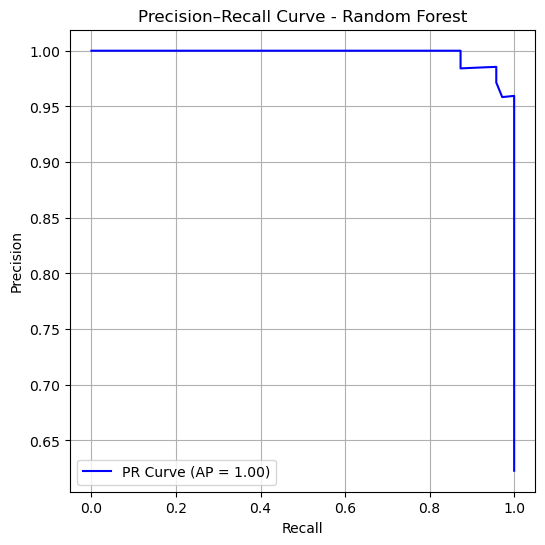

In [6]:
plt.figure(figsize=(6,6))

plt.plot(recall, precision, color="blue", label=f"PR Curve (AP = {ap_score:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Random Forest")
plt.legend()
plt.grid()
plt.show()

### What this shows
- X-axis → Recall
- Y-axis → Precision
- Curve closer to top-right → better model
- Useful for imbalanced datasets